In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import scanpy as sc
import anndata as ad
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scvi
import seaborn as sns
import torch

from scipy import io
import scipy
from scipy.sparse import coo_matrix, csr_matrix
import pickle
import matplotlib.pyplot as pl
from matplotlib import rcParams

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

import matplotlib.colors

sc.settings.set_figure_params(facecolor='white', dpi=100, frameon=False)

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import scanpy as sc
import anndata as ad
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scvi
import seaborn as sns
import torch

from scipy import io
import scipy
from scipy.sparse import coo_matrix, csr_matrix
import pickle
import matplotlib.pyplot as pl
from matplotlib import rcParams

sc.settings.set_figure_params(facecolor='white', dpi=100, frameon=False)

scvi.settings.seed = 0

import tempfile

sc.set_figure_params(figsize=(6, 6), frameon=False) #6x6
sns.set_theme()
torch.set_float32_matmul_precision("high")
save_dir = tempfile.TemporaryDirectory()

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

Seed set to 0


In [38]:
# load matrix
X = io.mmread("visvader.all.counts.mtx")

# create anndata object
adata = ad.AnnData(
    X=X.transpose().tocsr()
)

# load metadata
cell_meta = pd.read_csv("visvader.all.metadata.csv", low_memory=False)

# load gene names
with open("visvader.all.gene.names.csv", 'r') as f:
    gene_names = f.read().splitlines()

# set anndata observations and index obs by barcodes, var by gene names
adata.obs = cell_meta
adata.obs.index = adata.obs['barcode']
adata.var.index = gene_names

adata.obs.index.name = "cells"

In [39]:
full=adata

In [51]:
full.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'barcode'], dtype='object')

In [40]:
meta=sc.read_h5ad('merged_final_epithelial_states.h5ad')

In [41]:
meta=meta.raw.to_adata()

In [42]:
full = full[meta.obs_names,:].copy()

In [43]:
full = full[:,meta.var_names].copy()

In [44]:
meta.X=full.X

In [45]:
adata=meta

In [46]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import scanpy as sc
import anndata as ad
import os
import sys
sys.path.append('/data/homezvol3/tzhuravl/bin/bigsur/BigSur')
from BigSur.feature_selection import mcfano_feature_selection as mcfano

sc.pp.filter_genes(adata, min_cells=1)
adata.layers["counts"] = adata.X.copy()
mcfano(adata, layer='counts')

Using 0.01 for pvalue cutoff and 0.95 for mcfano quantile cutoff for highly variable genes.


/opt/apps/python/3.10.2/lib/python3.10/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


In [47]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo"], inplace=True, log1p=True
)

In [48]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [49]:
adata.raw = adata


adata = adata[:, adata.var.highly_variable].copy()
adata = adata.copy()
sc.pp.regress_out(adata, ['total_counts'])

In [50]:
adata

AnnData object with n_obs × n_vars = 95483 × 935
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'barcode', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'leiden'
    var: 'n_cells', 'mc_Fano', 'FDR_adj_pvalue', 'p_value', 'highly_variable', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'CV_for_mc_Fano_fit', 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [53]:
scvi.model.SCVI.setup_anndata(adata, batch_key="orig.ident", layer="counts")

In [54]:
scvi_ref = scvi.model.SCVI(
    adata,
    use_layer_norm="both",
    use_batch_norm="none",
    encode_covariates=True,
    dropout_rate=0.2,
    n_layers=2,
)
scvi_ref.train()

/opt/apps/python/3.10.2/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3 /opt/apps/python/3.10.2/lib/python3.10/site-package ...
/opt/apps/python/3.10.2/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3 /opt/apps/python/3.10.2/lib/python3.10/site-package ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/opt/apps/python/3.10.2/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HI

Epoch 84/84: 100%|██████████| 84/84 [1:29:39<00:00, 40.95s/it, v_num=1, train_loss_step=475, train_loss_epoch=458]  

`Trainer.fit` stopped: `max_epochs=84` reached.


Epoch 84/84: 100%|██████████| 84/84 [1:29:39<00:00, 64.04s/it, v_num=1, train_loss_step=475, train_loss_epoch=458]


In [55]:
work_dir = ''

scvi_ref_path = os.path.join(work_dir, "bigsur_scvi")
scvi_ref.save(scvi_ref_path, overwrite=True)

In [116]:
work_dir = ''

pickle.dump(scvi_ref,
            open(os.path.join(work_dir, 'bigsur_scvi_model.pkl'), 'wb'))

In [56]:
SCVI_LATENT_KEY = "X_scVI"

adata.obsm[SCVI_LATENT_KEY] = scvi_ref.get_latent_representation()

In [57]:
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.leiden(adata)
sc.tl.umap(adata)

In [69]:
sc.tl.leiden(adata, resolution = 0.5)

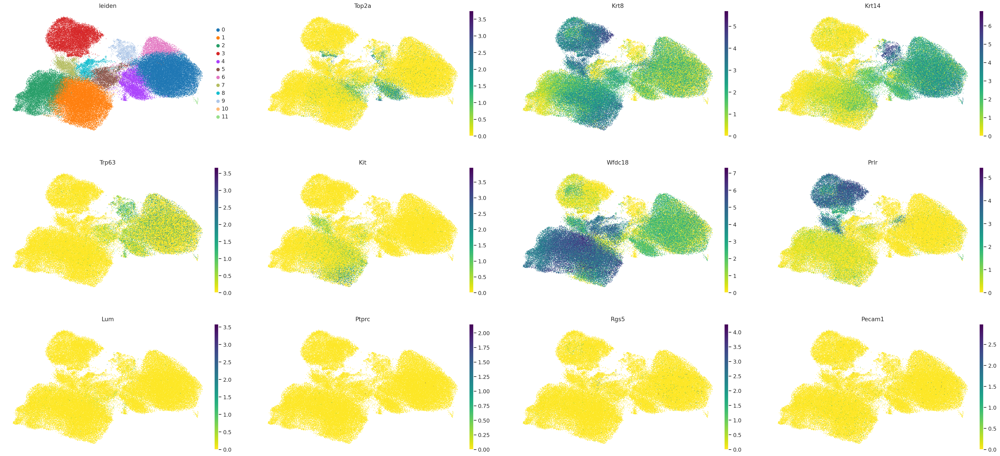

In [84]:
pl.rcParams["figure.figsize"] = (8,5)
sc.pl.umap(adata, color=["leiden", "Top2a", "Krt8", "Krt14", 
                         "Trp63", "Kit","Wfdc18","Prlr",
                        "Lum","Ptprc","Rgs5","Pecam1"], cmap = 'viridis_r',s=5,sort_order=None)

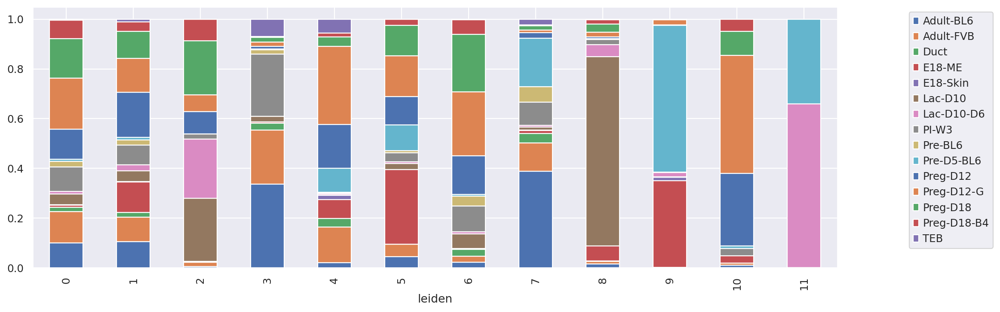

In [72]:
pl.rcParams["figure.figsize"] = (15,5)
tmp = pd.crosstab(adata.obs['orig.ident'],adata.obs['leiden'], normalize='columns').T.plot(kind='bar', stacked=True)
tmp.legend(title='', bbox_to_anchor=(1.2, 1.0),loc='upper right')

In [75]:
pd.crosstab(adata.obs['orig.ident'],adata.obs['leiden'])

leiden,0,1,2,3,4,5,6,7,8,9,10,11
orig.ident,,,,,,,,,,,,
Adult-BL6,2642,2503,53,4340,112,149,70,875,31,0,1,0
Adult-FVB,3385,2394,246,2826,818,169,71,259,22,2,1,0
Duct,444,465,2,349,196,4,86,84,1,0,0,0
E18-ME,261,2937,34,64,433,1017,8,29,124,677,3,0
E18-Skin,23,13,0,0,94,1,1,1,0,25,0,0
Lac-D10,1138,1051,3384,282,7,79,181,30,1546,3,0,0
Lac-D10-D6,278,594,3195,18,30,28,30,14,100,34,0,33
PI-W3,2637,1909,259,3233,15,121,317,209,41,4,3,0
Pre-BL6,614,477,1,223,18,31,125,140,0,1,0,0


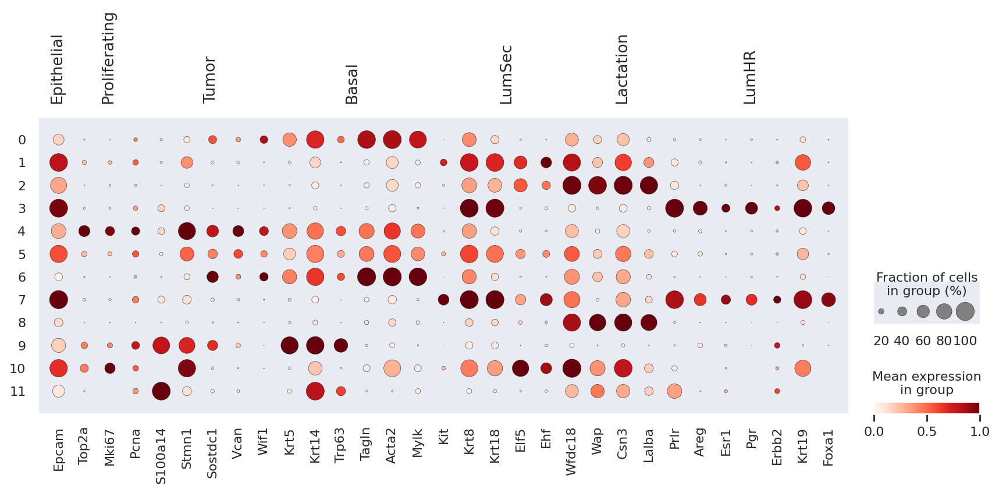

In [76]:
marker_genes = {
    "Epithelial": ["Epcam"],
    "Proliferating": ["Top2a", "Mki67","Pcna"],
    "Tumor": ["S100a14","Stmn1","Sostdc1","Vcan","Wif1"],
    "Basal": ["Krt5", "Krt14", "Trp63", "Tagln", "Acta2", "Mylk"],
    "LumSec": ["Kit", "Krt8", "Krt18","Elf5","Ehf","Wfdc18"],
    "Lactation": ["Wap","Csn3","Lalba"],
    "LumHR": ["Prlr", "Areg", "Esr1", "Pgr", "Erbb2", "Krt19","Foxa1"]
}

sc.pl.dotplot(adata, marker_genes, groupby="leiden", standard_scale="var")

In [78]:
adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'barcode',
       'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'leiden', '_scvi_batch',
       '_scvi_labels'],
      dtype='object')

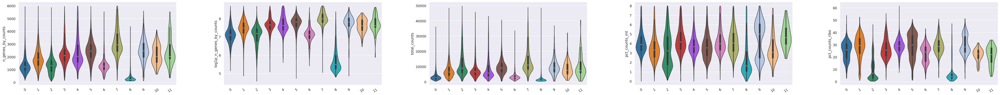

In [87]:
pl.rcParams["figure.figsize"] = (8,5)

sc.pl.violin(adata, ['n_genes_by_counts', 'log1p_n_genes_by_counts','total_counts',
                         'pct_counts_mt','pct_counts_ribo'], groupby="leiden", 
             rotation=30, 
             stripplot=False,
             inner='box')

In [107]:
adata.obs["cell_type"] = adata.obs["leiden"].map(
    {
        "0": "Basal_myoepithelial",
        "1": "Luminal_sec",
        "2": "Luminal_sec",
        "3": "Luminal_HS",
        "4": "Basal_myoep_proliferating",
        "5": "Basal_myo_luminal_sec",
        "6": "Basal_myoepithelial",
        "7": "Luminal_HS",
        "8": "Lactation",
        "9": "Basal",
        "10": "Lactation",
        "11": "Basal"
    }
)

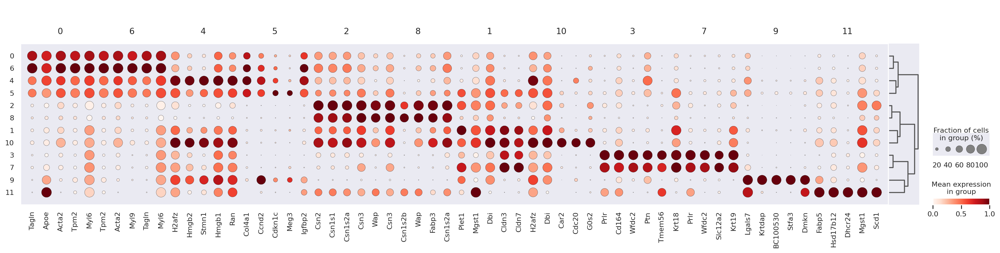

In [83]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")
sc.tl.dendrogram(adata, groupby = "leiden")

sc.pl.rank_genes_groups_dotplot(
    adata, groupby="leiden", standard_scale="var", n_genes=5
)

In [85]:
df_Unk = sc.get.rank_genes_groups_df(adata, '11')
df_Unk = df_Unk[df_Unk['pvals_adj'] < 0.05]
df_Unk = df_Unk[df_Unk['logfoldchanges'] > 1.5]
df_Unk.to_csv("celltype_to_confirm.csv")

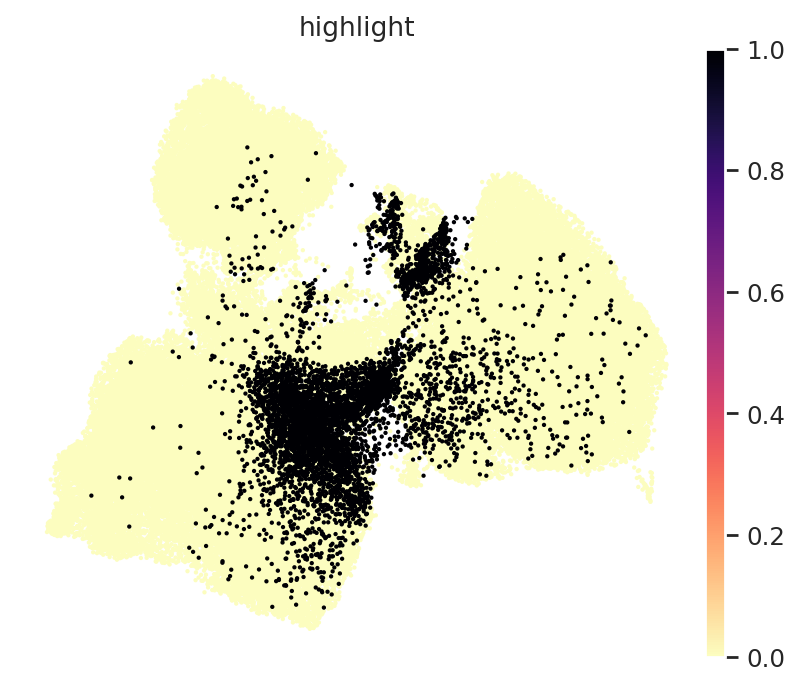

In [96]:
pl.rcParams["figure.figsize"] = (6,5)

adata.obs['highlight'] = pd.Categorical((adata.obs_vector('orig.ident') == "E18-ME"))
adata.obs['highlight'] = (
    adata.obs["highlight"]
    .map(lambda x: {"False": "0",
                   "True": "1"}.get(x, x))
    .astype('int32'))
sc.pl.umap(adata, color='highlight',s=15,cmap='magma_r')

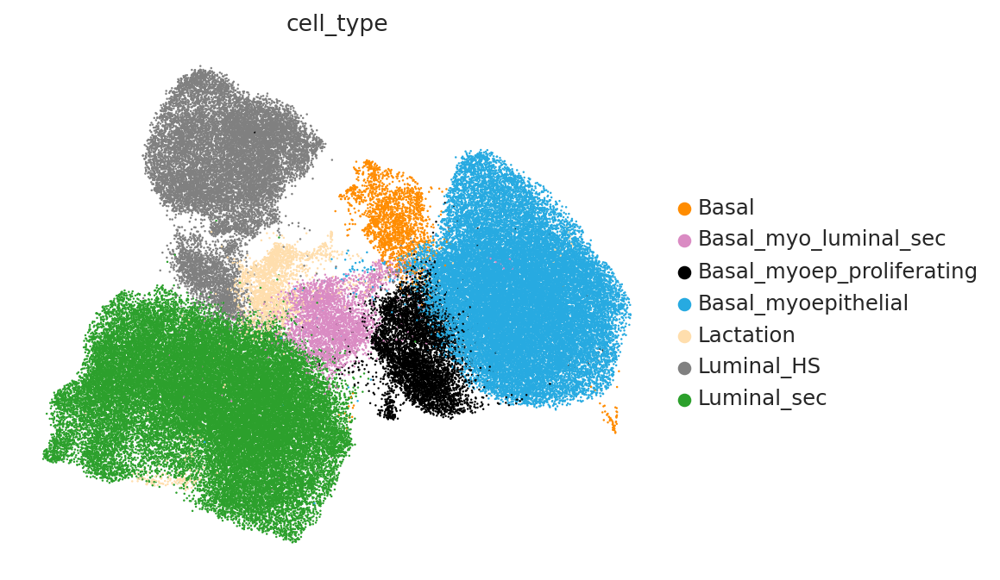

In [110]:
pl.rcParams["figure.figsize"] = (6,5)
sc.pl.umap(adata, color=["cell_type"],
           s=5,palette=['darkorange', '#da8bc3', 'black', '#27AAE1',
                         'navajowhite','grey','#2ca02c'])

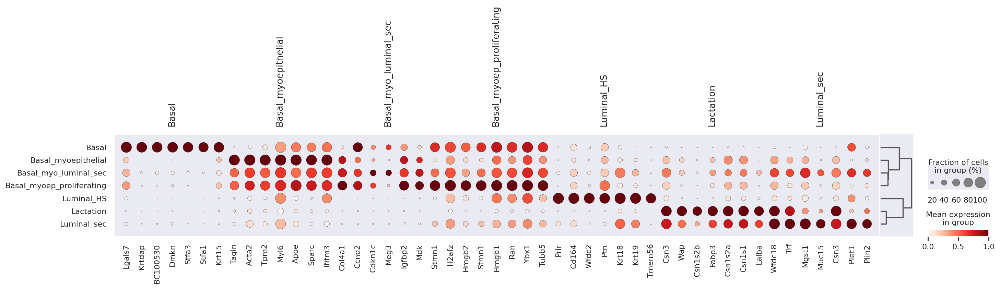

In [111]:
sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon")
sc.tl.dendrogram(adata, groupby = "cell_type")

sc.pl.rank_genes_groups_dotplot(
    adata, groupby="cell_type", standard_scale="var", n_genes=7
)

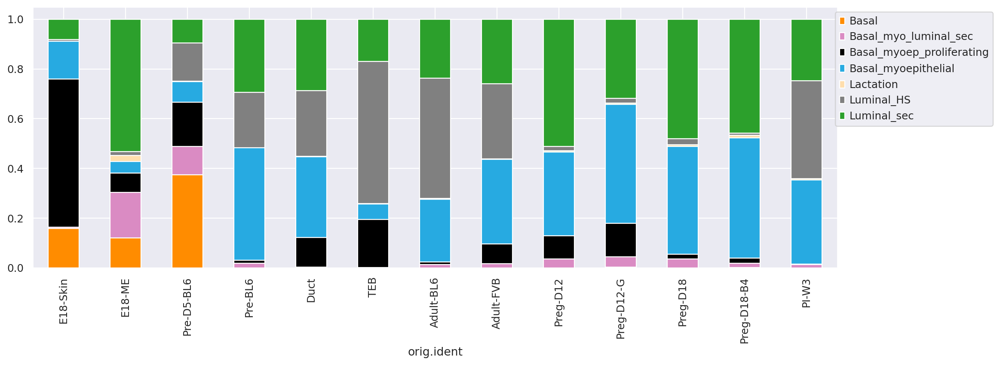

In [112]:
pl.rcParams["figure.figsize"] = (15,5)
tmp = pd.crosstab(adata.obs['cell_type'],adata.obs['orig.ident'], normalize='columns').reindex()[['E18-Skin','E18-ME',
                                                                                                  'Pre-D5-BL6','Pre-BL6','Duct','TEB',
                                                                                                 'Adult-BL6','Adult-FVB',
                                                                                                  'Preg-D12','Preg-D12-G','Preg-D18','Preg-D18-B4',
                                                                                                 'PI-W3']].T.plot(kind='bar', stacked=True, 
                                                                                                                  color=['darkorange', '#da8bc3', 'black', '#27AAE1',
                         'navajowhite','grey','#2ca02c'])
tmp.legend(title='', bbox_to_anchor=(1.2, 1.0),loc='upper right')

In [113]:
work_dir = ''

pickle.dump(adata,
            open(os.path.join(work_dir, 'visvader_ref_scvi_bigsur_repeat_2.pkl'), 'wb'))

In [114]:
adata.write("visvader_ref_scvi_bigsur_repeat_2.h5ad")

In [115]:
adata

AnnData object with n_obs × n_vars = 95483 × 935
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'barcode', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'leiden', '_scvi_batch', '_scvi_labels', 'highlight'
    var: 'n_cells', 'mc_Fano', 'FDR_adj_pvalue', 'p_value', 'highly_variable', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'CV_for_mc_Fano_fit', 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'umap', '_scvi_uuid', '_scvi_manager_uuid', 'rank_genes_groups', 'dendrogram_leiden', 'dendrogram_cell_type'
    obsm: 'X_pca', 'X_

In [ ]:
# try scvi here